<font color='green'> <br>
    ***********************************************************************************************  <br><br>
    &emsp; Deep Learning Project:&emsp; drone-vision-transformer <br><br>
    &emsp; Author:&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&nbsp; Uttara Naidu <br><br>
    &emsp; Date:&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp; 11/04/2026 <br><br>
    &emsp; Version: &emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;v0.1 (WIP) <br><br>
    &emsp; Description:&emsp;&emsp;&emsp;&emsp;&emsp;&emsp; Creates a ViT+RL model for inference in drone controller <br><br>
    ***********************************************************************************************  <br>
 </font>

<font color='blue'> NOTE: This is a work-in-progress. Code clean-up, documentation and further updates will follow soon. </font>

The dataset is downloaded from: https://fpv.ifi.uzh.ch/datasets/

*Indoor forward facing:* 

Rogbag file: indoor_forward_5_snapdragon_with_gt.bag


In [1]:
from rosbags.highlevel import AnyReader
from pathlib import Path
import numpy as np

import sys, warnings

bag_path = Path('/Users/uni/data_files/fpv/indoor_forward_5_snapdragon_with_gt.bag')                # Path to downloaded .bag file
PROJ_DIR = '/Users/uni/dl_project_workspace/drone-vision-transformer'
DATA_DIR =  f'{PROJ_DIR}/data'
sys.path.append('/Users/uni/dl_project_workspace/drone-vision-transformer/')

from scripts.data_loader import explore_data, extract_data
from scripts.transformer import VisionTransformer, ViTDataset

explore_data()

TOPIC                          | MSG TYPE                       | COUNT     
---------------------------------------------------------------------------
/groundtruth/odometry          | nav_msgs/msg/Odometry          | 9650      
/groundtruth/pose              | geometry_msgs/msg/PoseStamped  | 9650      
/snappy_cam/stereo_l           | sensor_msgs/msg/Image          | 4162      
/snappy_cam/stereo_r           | sensor_msgs/msg/Image          | 4162      
/snappy_imu                    | sensor_msgs/msg/Imu            | 75042     


In [2]:
extract_data(DATA_DIR)

----------- NUMBER OF DATA POINTS -----------
Images:8324 | IMU:75042 | Odometry:9650 | Pose:9650
Dataset created with 8324 synchronized rows.
Saved 75042 IMU messages to imu_data.csv


In [3]:
import pandas as pd

data = pd.read_csv('drone_dataset.csv')
data.head()

,timestamp,cam_id,img_path,imu_start_ts,imu_end_ts,pos_x,pos_y,pos_z,ori_w,vel_x,vel_y,vel_z
0,1540821095628558395,0,/Users/uni/dl_project_workspace/drone-vision-t...,1.540821e+18,1.540821e+18,7.481608,-0.005923,-0.907926,-0.455032,0.0,0.0,0.0
1,1540821095628558395,1,/Users/uni/dl_project_workspace/drone-vision-t...,1.540821e+18,1.540821e+18,7.481608,-0.005923,-0.907926,-0.455032,0.0,0.0,0.0
2,1540821095661733604,0,/Users/uni/dl_project_workspace/drone-vision-t...,1.540821e+18,1.540821e+18,7.481608,-0.005923,-0.907926,-0.455032,0.0,0.0,0.0
3,1540821095661733604,1,/Users/uni/dl_project_workspace/drone-vision-t...,1.540821e+18,1.540821e+18,7.481608,-0.005923,-0.907926,-0.455032,0.0,0.0,0.0
4,1540821095694906448,0,/Users/uni/dl_project_workspace/drone-vision-t...,1.540821e+18,1.540821e+18,7.481608,-0.005923,-0.907926,-0.455032,0.0,0.0,0.0


In [4]:
imu_df = pd.read_csv('imu_data.csv')
imu_df.head()

,timestamp,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z
0,1540821095597876000,-0.124498,-0.220265,9.691679,-0.009587,-0.003196,-0.001065
1,1540821095599871000,-0.110133,-0.220265,9.706043,-0.006392,-0.004261,-0.002131
2,1540821095601871000,-0.124498,-0.186747,9.677314,-0.006392,-0.002131,-0.005326
3,1540821095603869000,-0.110133,-0.225054,9.725197,-0.004261,0.001065,-0.003196
4,1540821095605868000,-0.105344,-0.205900,9.753927,-0.001065,-0.003196,-0.002131


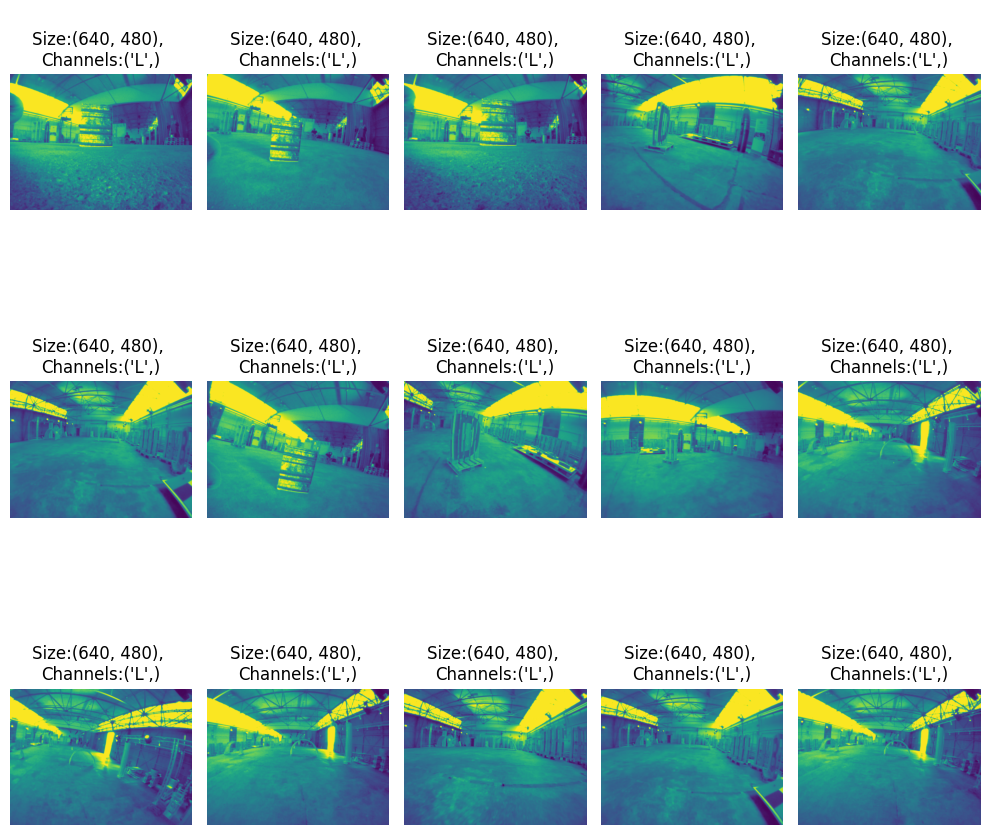

In [5]:
from PIL import Image
import matplotlib.pyplot as plt
import random

fig, ax = plt.subplots(3,5,figsize=(10,10))
axes_flat = ax.flatten()

random_idx = [random.randint(1,8000) for _ in range(15)]

for ax,idx in zip(axes_flat,random_idx):
    img = Image.open(data['img_path'][idx])
    ax.imshow(img)
    ax.set_title(f'\nSize:{img.size}, \nChannels:{img.getbands()}')
    ax.axis('off')

plt.tight_layout() 
plt.show()

In [6]:
from torchinfo import summary

model = VisionTransformer(num_classes=None, img_size=(256,256))
summary(model, input_size=(1,1,256,256))

Layer (type:depth-idx)                   Output Shape              Param #
VisionTransformer                        [1, 256]                  66,048
├─PatchEmbed: 1-1                        [1, 256, 256]             --
│    └─Linear: 2-1                       [1, 256, 256]             65,792
├─ModuleList: 1-2                        --                        --
│    └─TransformerEncoderBlock: 2-2      [1, 257, 256]             --
│    │    └─MultiHeadAttention: 3-1      [1, 257, 256]             263,168
│    │    └─Dropout: 3-2                 [1, 257, 256]             --
│    │    └─LayerNorm: 3-3               [1, 257, 256]             512
│    │    └─Sequential: 3-4              [1, 257, 256]             262,912
│    │    └─Dropout: 3-5                 [1, 257, 256]             --
│    │    └─LayerNorm: 3-6               [1, 257, 256]             512
│    └─TransformerEncoderBlock: 2-3      [1, 257, 256]             --
│    │    └─MultiHeadAttention: 3-7      [1, 257, 256]           

In [7]:
import torch

# iMac-specific setup
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

dataset = ViTDataset('drone_dataset.csv','imu_data.csv',DATA_DIR)